# The region word

Every region of a circular diagram carries a **word**: read the colours of the
edges crossed on the way from the marked region to it. The word is what tells the
driver whether a diagram is a normal form — a region whose word is not reduced
marks a place where two same-coloured strands can still be fused.

This notebook works through the definition on examples, and through the trap that
comes with it: there are **two** region words, belonging to two different
distances, and they do not agree.


In [1]:
using DiagrammaticHecke
debug_circular(true)
dl_warnings!(false)

"""Draw a circular morphism with the REGION-WORD TREE on top: region number and
word in each region, one labelled arrow per tree edge. Every picture in this
notebook uses it, so the word under discussion is always visible."""
rwshow(m::CircularMorphismGraph) =
    display("image/svg+xml",
            circular_tutte_svg(m; cell_numbers = true, cell_labels = :words_num,
                               region_tree = true, slot_numbers = false,
                               leaf_numbers = false))
rwshow(fdm::CircularDecoratedMorphism) = rwshow(fdm.m)

rwshow (generic function with 2 methods)

## 1. How the word is computed

The regions of a diagram form a tree: the **marked** region is the root, and
every other region is reached from it by crossing one edge at a time. Crossing
an edge of colour `s` appends the letter `s`. The region word of `R` is what
the crossed colours spell along the path from the mark to `R`.

The example — 4 nodes, 5 regions, 8 boundary leaves — is written out rather
than computed, so this notebook needs nothing but the circular layer. `circular_region_distances` gives the depth in that tree, so the marked
region is the one at distance `0`.

In [2]:
NP = NodePort
g0 = CircularGraph(CircularWord([1,1,2,1,2,2,1,2]),
     CircularNode[circular_node([1]), circular_node([2,2,2]),
                  circular_node([1]), circular_node([2,2,2])],
     Edge[Edge(1, Leaf(3), NP(1,1)), Edge(2, Leaf(2), NP(2,2)),
          Edge(2, Leaf(4), NP(2,1)), Edge(1, Leaf(6), NP(3,1)),
          Edge(1, Leaf(1), Leaf(8)), Edge(2, Leaf(7), NP(4,1)),
          Edge(2, Leaf(5), NP(4,2)), Edge(2, NP(2,3), NP(4,3))])
m = CircularMorphismGraph(g0, 0, 4)
@show euler(g0) isempty(check_wiring(g0)) region_count(g0)
circular_region_distances(m)

euler(g0) = 

2
isempty(check_wiring(g0)) = true
region_count(g0) = 5


5-element Vector{Int64}:
 2
 1
 2
 2
 0

`region_tree = true` draws that tree into the picture: one arrow per tree edge,
labelled with the colour crossed there, starting at the marked region (the one
with the ring). Reading the arrow labels from the mark to a region spells out
exactly that region's word — the picture and the list above are the same
statement.

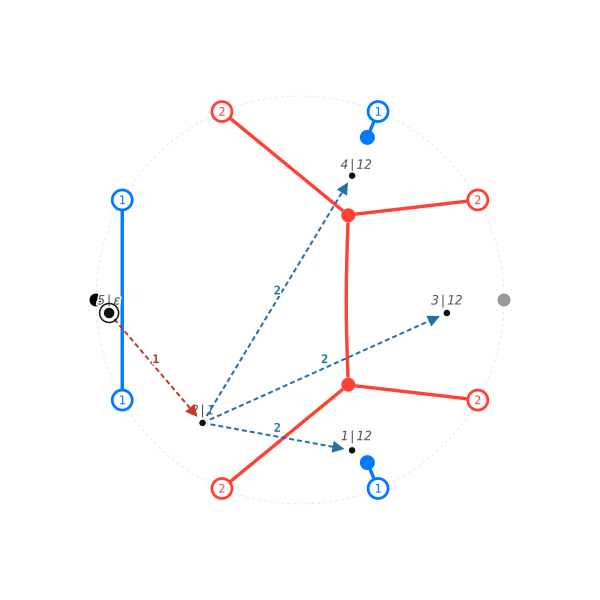

In [3]:
rwshow(m)

`circular_path_edges(m, R)` is the same walk as data: which regions the path
visits, which edges it crosses, and the word those edges spell. Region 5 is the
mark, so its word is `ε`; regions 1, 3 and 4 sit two crossings out.

In [4]:
for R in 1:region_count(g0)
    p = circular_path_edges(m, R)
    println("region ", R, ":  via regions ", p.regions, "   crossing edges ", p.edges,
            "   colours ", [g0.edges[e].colour for e in p.edges], "   word ", p.word)
end

region 

1:  via regions 

[5, 2, 1]   crossing edges [5, 2]   colours [1, 2]   word [1, 2]
region 2:  via regions [5, 2]   crossing edges [5]   colours [1]   word [1]
region 3:  via regions [5, 2, 3]   crossing edges [5, 8]   colours [1, 2]   word [1, 2]
region 4:  via regions [5, 2, 4]   crossing edges [5, 6]   colours [1, 2]   word [1, 2]
region 5:  via regions [5]   crossing edges Int64[]   colours Any

[]   word Int64[]


Every word here is reduced — no letter repeats along a path — so this diagram
is a normal form as far as the criterion is concerned. Section 3 shows what an
UNREDUCED one looks like and what the driver does with it.

## 2. The marking is part of the question

A `CircularGraph` has no cuts, so it has no marked region either — only a
`CircularMorphismGraph` does. The region word is measured from that mark, and
moving the mark changes every word.

The minimal figure: two parallel 1-strands across the disc, four regions of which
three are inner. With the mark at `0|2` the words are `ε`, `1`, `11`.

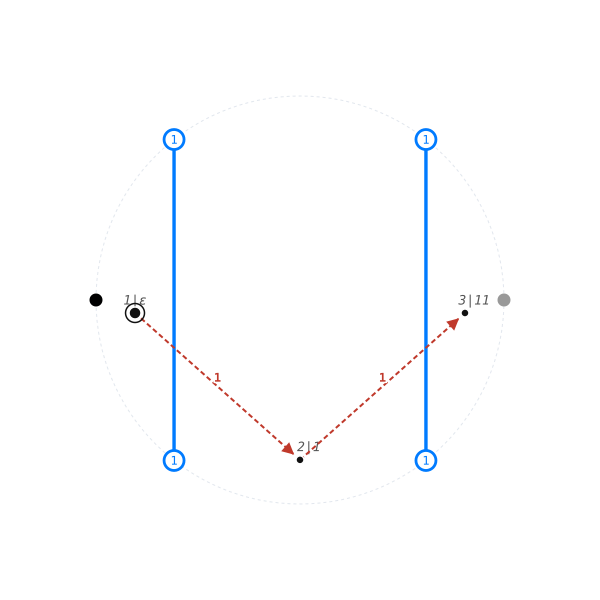

distances:    [0, 1, 2]
region words: 

Union{Nothing, Vector{Int64}}[Int64[], [1], [1, 1]]


In [5]:
par = CircularGraph(CircularWord([1, 1, 1, 1]), CircularNode[],
                    Edge[Edge(1, Leaf(1), Leaf(4)), Edge(1, Leaf(2), Leaf(3))])
m_out = CircularMorphismGraph(par, 0, 2)
rwshow(m_out)
println("distances:    ", circular_region_distances(m_out))
println("region words: ", circular_region_tree_words(m_out))

`11` is **not reduced** — `s·s = e`. So this diagram is not a normal form, and
the place to act is where the word steps from `1` to `11`.

In [6]:
T = circular_unreduced_transition(m_out)
println("region ", T.region, ", word ", T.word, ", colour ", T.colour,
        ", kind ", T.kind, ", case ", T.case)
println("the pair to fuse: ", (T.prev_edge, T.edge))

region 2, word [1], colour 1, kind edge, case direct
the pair to fuse: 

(1, 2)


Now move the mark into the middle. The same diagram, the same edges — but the
words become `1`, `ε`, `1`, all reduced, and nothing fires.

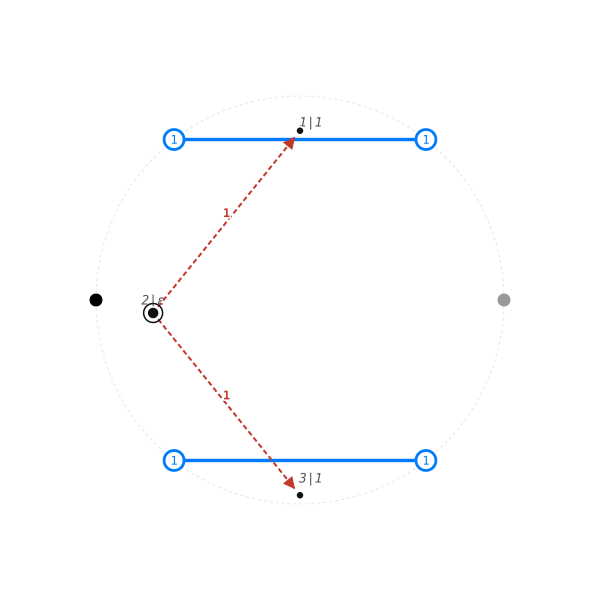

distances:    [1, 0, 1]
region words: Union{Nothing, Vector{Int64}}[[1], Int64[], [1]]
transition:   none


In [7]:
m_mid = CircularMorphismGraph(par, 1, 3)
rwshow(m_mid)
println("distances:    ", circular_region_distances(m_mid))
println("region words: ", circular_region_tree_words(m_mid))
println("transition:   ", circular_unreduced_transition(m_mid) === nothing ? "none" : "found")

That is not a defect. The word answers "how do I get there from the marking",
and a different marking is a different question. What it means in practice: never
read a region word off a diagram without saying which marking it belongs to.

## 3. Two words, two distances

`circular_region_tree_words` and `circular_region_words` are **not** the same
function, and the difference bites.

| function | tree it walks | matching distance |
|---|---|---|
| `circular_region_tree_words` | the node-weighted tree | `circular_region_distances` |
| `circular_region_words` | the level BFS over edges only | `circular_region_distances_edges_only` |

The node-weighted distance counts a step through a `:gen2`/`:gen13` node as the
number of colours crossed, so two regions that share only a node are still
neighbours. The edge-only distance counts genuine edges. The invariant to hold on
to is `length(tree_word[R]) == circular_region_distances(m)[R]`.

Here is a diagram where they disagree. It has a 6-armed single-colour node, and
it is written out rather than computed: it turns up as one term of the
decomposition of `21232 → 21232` (notebook 10), but building it directly keeps
this notebook independent of the bases — and saves the reader a quarter minute
of compilation.

euler(g) = 2
isempty(check_wiring(g)) = true
region_count(g) = 6


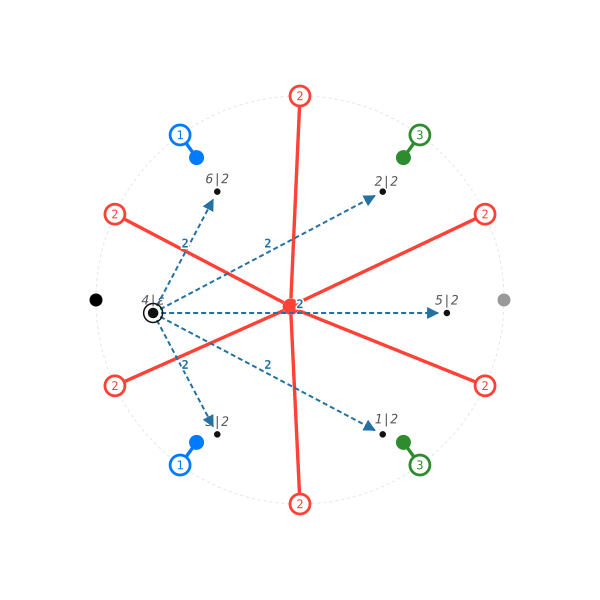

node 1

: mixed  arms [3]
node 2: mixed  arms [3]
node 3: mono  arms [2, 2, 2, 2, 2, 2]
node 4: mixed  arms [1]
node 5: mixed  arms [1]


In [8]:
NP = NodePort
g = CircularGraph(CircularWord([1,2,2,1,2,3,2,2,3,2]),
    CircularNode[circular_node([3]), circular_node([3]), circular_node(fill(2, 6)),
                 circular_node([1]), circular_node([1])],
    Edge[Edge(3, Leaf(4), NP(1,1)), Edge(3, Leaf(7), NP(2,1)),
         Edge(2, Leaf(3), NP(3,3)), Edge(2, Leaf(1), NP(3,4)),
         Edge(2, Leaf(5), NP(3,2)), Edge(1, Leaf(2), NP(4,1)),
         Edge(2, Leaf(6), NP(3,1)), Edge(1, Leaf(9), NP(5,1)),
         Edge(2, Leaf(8), NP(3,6)), Edge(2, Leaf(10), NP(3,5))])
m = CircularMorphismGraph(g, 0, 5)
@show euler(g) isempty(check_wiring(g)) region_count(g)
rwshow(m)
for (i, nd) in enumerate(g.nodes)
    println("node ", i, ": ", nd.kind, "  arms ", arms(nd))
end

In [9]:
println("distances (node-weighted): ", circular_region_distances(m))
println("distances (edges only):    ", circular_region_distances_edges_only(m))
println()
println("circular_region_tree_words: ", circular_region_tree_words(m))
println("circular_region_words:      ", circular_region_words(m)[1])

distances (node-weighted): [1, 1, 1, 0, 1, 1]
distances (edges only):    [2, 2, 1, 0, 3, 1]

circular_region_tree_words: Union{Nothing, Vector{Int64}}[[2], [2], [2], Int64[], [2], [2]]
circular_region_words:      Union{Nothing, Vector{Int64}}[[2, 2], [2, 2], [2], Int64[], [2, 2, 2], [2]]


The tree words are `2`, `2`, `2`, `ε`, `2` — every one of them reduced. The
edge-only words are `2`, `22`, `2`, `ε`, `22`, and `22` is not reduced.

**Which one decides?** The one that belongs to the distance the rules use.
`circular_unreduced_transition` reads the node-weighted tree, so this term is a
normal form and no rule fires — correctly.

In [10]:
println("transition: ", circular_unreduced_transition(m) === nothing ? "none" : "found")
println("driver:     ", reduce_circular(g)[2])

transition: none


driver:     Symbol[]


Reading the other variant here and concluding "the word `22` is unreduced, so
something must fire" is the trap. The `22` comes from walking two edges where the
node-weighted tree walks one.

## 4. What the transition looks for

`circular_unreduced_transition` does not look for an unreduced word. It looks for
the **step** that makes a word unreduced: the shortest region whose word `w` is
reduced while `w·s`, one `s`-edge further, is not. The result names

* `region` and `word` — where the reduced word sits,
* `colour` and `edge` — the step that breaks it,
* `prev_edge` — the tree parent edge, which is the fusion partner,
* `kind` — `:edge` (a boundary edge) or `:dot` (a dot's cap edge),
* `case` — `:direct`, `:dihedral` or `:long`, i.e. how many braid moves it takes
  to bring `w·s` into a form where the two `s`-strands are adjacent.

The three cases are what decides which rule runs.

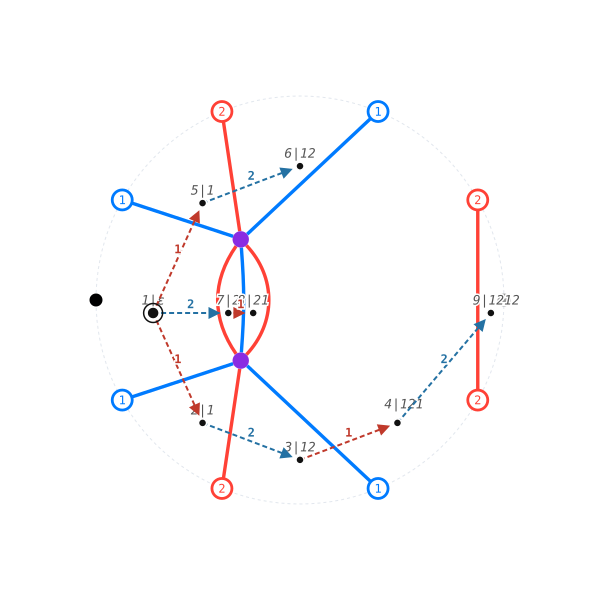

region 4, word [1, 2, 1], colour 2, kind edge, case dihedral


In [11]:
function rex_cycle_fdm(w::Vector{Int}, i::Int)
    wp, _ = braid_to_end_with(w, i)
    f = braid_top_to(light_leaf_up(w), wp)
    fm = circular_morphism(tensor(compose(f, flip(f)), identity_strand(i)))
    return CircularDecoratedMorphism(fm, fill(one(SoergelPoly), region_count(fm.graph)))
end
fdm = rex_cycle_fdm([1, 2, 1], 2)
rwshow(fdm)
T2 = circular_unreduced_transition(fdm.m)
println("region ", T2.region, ", word ", T2.word, ", colour ", T2.colour,
        ", kind ", T2.kind, ", case ", T2.case)

`case == :dihedral`: the word is `121`, the step adds a `2`, and `1212` needs one
braid move before the two 2-strands lie side by side. That is the case rex fusion
handles with a derived relation; `:direct` is the plain fusion surgery.

In [12]:
println("region words along the tree: ", circular_region_tree_words(fdm.m))
println("path of edges to that region:  ", circular_path_edges(fdm.m, T2.region))

region words along the tree: Union{Nothing, Vector{Int64}}[Int64[], [1], [1, 2], [1, 2, 1], [1], [1, 2], [2], [2, 1], [1, 2, 1, 2]]
path of edges to that region:  

(edges = [1, 2, 3], word = [1, 2, 1], regions = [1, 2, 3, 4])


## 5. A dot transition

A dot's cap edge counts as a continuation too — then `kind` is `:dot`, and the
step belongs to `circular_dot_fusion_step` rather than to rex fusion.

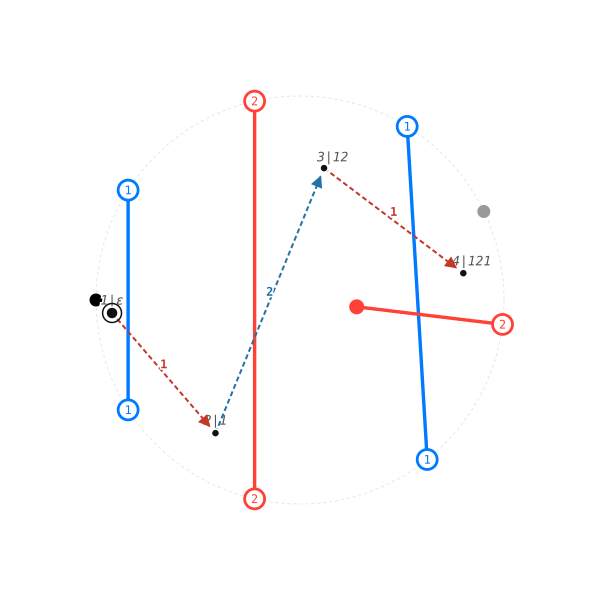

region 4, word [1, 2, 1], colour 2, kind dot, case dihedral
the dot's distance word: [1, 2, 1]
reducible dots:          

[1]


In [13]:
NP = NodePort
gB = CircularGraph(CircularWord([1, 2, 1, 2, 1, 2, 1]), CircularNode[circular_node([2])],
                   Edge[Edge(1, Leaf(2), Leaf(1)), Edge(2, Leaf(3), Leaf(7)),
                        Edge(1, Leaf(4), Leaf(6)), Edge(2, Leaf(5), NP(1, 1))])
mB = CircularMorphismGraph(gB, 1, 5)
fdmB = CircularDecoratedMorphism(mB, fill(one(SoergelPoly), region_count(gB)))
rwshow(fdmB)
TB = circular_unreduced_transition(mB)
println("region ", TB.region, ", word ", TB.word, ", colour ", TB.colour,
        ", kind ", TB.kind, ", case ", TB.case)
println("the dot's distance word: ", circular_distance_word(mB, 1))
println("reducible dots:          ", circular_non_normal_dots(mB))

Two criteria meet here. The region word sees the strands, the distance word
`circular_distance_word` sees the dot: can it be braided to end on the dot's own
colour, i.e. pulled home? On this figure both say yes, and the `:dot` kind sends
the work to dot fusion.

## 6. Where the region word is used

* `circular_unreduced_transition` — the trigger of `circular_rex_fusion_step` and
  of `circular_dot_fusion_step`.
* 2parallel — condition 4 of the rule takes its pair from the transition
  (`find_circular_2parallel`), so both rules fire at the same site.
* `circular_regionword_dihedral_step` — the dihedral case done by hand.
* `circular_path_edges` — the tree path to a region, as an edge list; with the
  transition edge appended its colours read `w·s`, which is the cut curve rex
  fusion splices along.

The variants `circular_region_words_2k` and `circular_region_mvalent_words` read
the same tree with a different alphabet, for figures with many-armed nodes.

In [14]:
println("dot fusion on: ", CIRCULAR_DOT_FUSION_ENABLED[])
println("rex fusion on: ", CIRCULAR_REX_FUSION_ENABLED[])
println("dot policy on: ", CIRCULAR_DOT_POLICY[])

dot fusion on: true
rex fusion on: true
dot policy on: true
